## Часть 1. EDA
Датасет предсказание Customer Livetime Value.

In [1]:
debug = 0

In [2]:
# Общие полезные функции

def log(message):
    if debug == 1:
        print(f"[DEBUG] {message}")

log("Функция log готова. Использование: log(message), будет отображено при включенной отладке.")


In [3]:
# Загрузка требуемых библиотек
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

In [4]:
# log(plt.colormaps())

In [5]:
# Загрузка датасета
path = kagglehub.dataset_download("pankajjsh06/ibm-watson-marketing-customer-value-data")

log("Path to dataset files:" + path)

In [6]:
# Читаем CSV
files = os.listdir(path)
log("Files: " + str(files))

df = pd.read_csv(os.path.join(path, files[0]))

rows, cols = df.shape
log(f"Размер данных: {rows} строк и {cols} колонок")

In [7]:
df.head()  # шапка данных

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [8]:
df.info()  # типы данных, количество не-null значений

df.describe(include='all') #базовая статисктика

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
count,9134,9134,9134.000000,9134,9134,9134,9134,9134,9134,9134.000000,...,9134.000000,9134.000000,9134.000000,9134,9134,9134,9134,9134.000000,9134,9134
unique,9134,5,NaN,2,3,5,59,5,2,NaN,...,NaN,NaN,NaN,3,9,4,4,NaN,6,3
top,Y167826,California,NaN,No,Basic,Bachelor,1/10/11,Employed,F,NaN,...,NaN,NaN,NaN,Personal Auto,Personal L3,Offer1,Agent,NaN,Four-Door Car,Medsize
freq,1,3150,NaN,7826,5568,2748,195,5698,4658,NaN,...,NaN,NaN,NaN,6788,3426,3752,3477,NaN,4621,6424
mean,NaN,NaN,8004.940475,NaN,NaN,NaN,NaN,NaN,NaN,37657.380009,...,48.064594,0.384388,2.966170,NaN,NaN,NaN,NaN,434.088794,NaN,NaN
std,NaN,NaN,6870.967608,NaN,NaN,NaN,NaN,NaN,NaN,30379.904734,...,27.905991,0.910384,2.390182,NaN,NaN,NaN,NaN,290.500092,NaN,NaN
min,NaN,NaN,1898.007675,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,0.099007,NaN,NaN
25%,NaN,NaN,3994.251794,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,24.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,272.258244,NaN,NaN
50%,NaN,NaN,5780.182197,NaN,NaN,NaN,NaN,NaN,NaN,33889.500000,...,48.000000,0.000000,2.000000,NaN,NaN,NaN,NaN,383.945434,NaN,NaN
75%,NaN,NaN,8962.167041,NaN,NaN,NaN,NaN,NaN,NaN,62320.000000,...,71.000000,0.000000,4.000000,NaN,NaN,NaN,NaN,547.514839,NaN,NaN


In [9]:
# Из чего состоят для приведения в будущем
for col in df.columns:
    log(f"Столбец {col}: {df[col].unique()}\n")

In [10]:
# Рекоммендации по обработке признаков

binary_cols = []
categorical_cols = []
high_cardinality_cols = []
numeric_cols = []

# Распределяем столбцы по спискам
for col in df.columns:
    if df[col].dtype == 'object':
        n_unique = df[col].nunique()
        if n_unique == 2:
            binary_cols.append(col)
        elif n_unique <= 10:
            categorical_cols.append(col)
        else:
            high_cardinality_cols.append(col)
    else:
        numeric_cols.append(col)

log(f"Бинарные (перевести в 0/1): {binary_cols}")
log(f"Категориальные (<= 10 знач., нужен One-Hot / Label): {categorical_cols}")
log(f"Много значений (текст, ID или много категорий): {high_cardinality_cols}")
log(f"Числовые (оставить как есть / масштабировать): {numeric_cols}")

## Анализ Целевых переменных

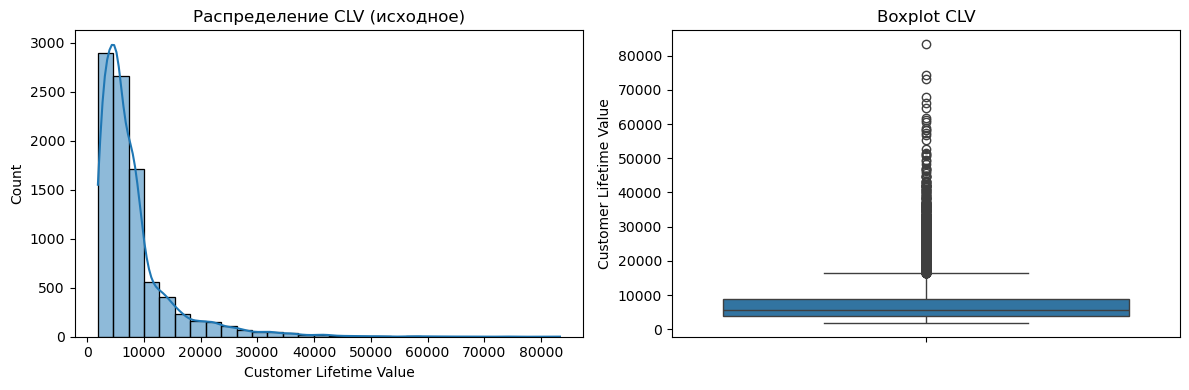

In [11]:
clv = df['Customer Lifetime Value']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма с KDE
sns.histplot(clv, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Распределение CLV (исходное)')

# Boxplot
sns.boxplot(y=clv, ax=axes[1])
axes[1].set_title('Boxplot CLV')

plt.tight_layout()
plt.show()

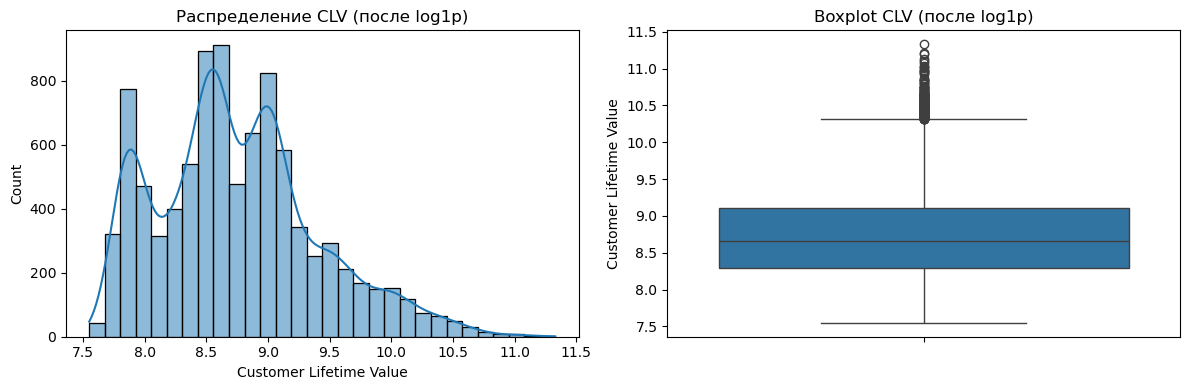

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма с KDE
sns.histplot(np.log1p(clv), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Распределение CLV (после log1p)')

# Boxplot
sns.boxplot(y=np.log1p(clv), ax=axes[1])
axes[1].set_title('Boxplot CLV (после log1p)')

plt.tight_layout()
plt.show()

## Выбросы численно:

In [13]:
Q1 = clv.quantile(0.25)
Q3 = clv.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(clv < lower_bound) | (clv > upper_bound)]
log(f"Количество выбросов: {len(outliers)}")
print(f"Доля выбросов CLV: {len(outliers)/len(df):.2%}")

Доля выбросов CLV: 8.94%


## Оценка дисбаланса Response

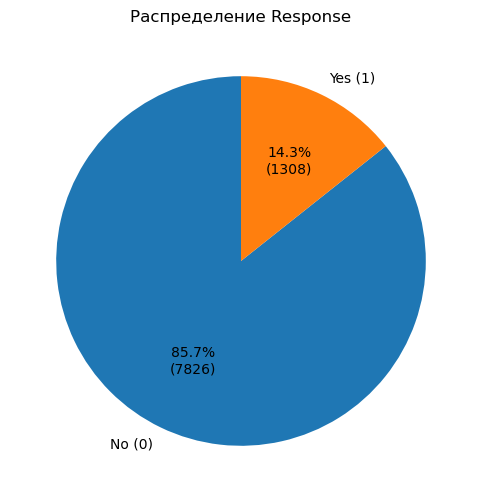

In [14]:
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return my_autopct

labels = ['No (0)', 'Yes (1)']  # подписи
counts = df['Response'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct=make_autopct(counts), startangle=90)
plt.title('Распределение Response')
plt.show()

## Описательная статистика для числовых признаков

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
log("Числовые признаки:"+ str(num_cols))
df[num_cols].describe()

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,15.097000,48.064594,0.384388,2.966170,434.088794
std,6870.967608,30379.904734,34.407967,10.073257,27.905991,0.910384,2.390182,290.500092
min,1898.007675,0.000000,61.000000,0.000000,0.000000,0.000000,1.000000,0.099007
25%,3994.251794,0.000000,68.000000,6.000000,24.000000,0.000000,1.000000,272.258244
50%,5780.182197,33889.500000,83.000000,14.000000,48.000000,0.000000,2.000000,383.945434
75%,8962.167041,62320.000000,109.000000,23.000000,71.000000,0.000000,4.000000,547.514839
max,83325.381190,99981.000000,298.000000,35.000000,99.000000,5.000000,9.000000,2893.239678


## Коррекляции числовых признаков


<Axes: >

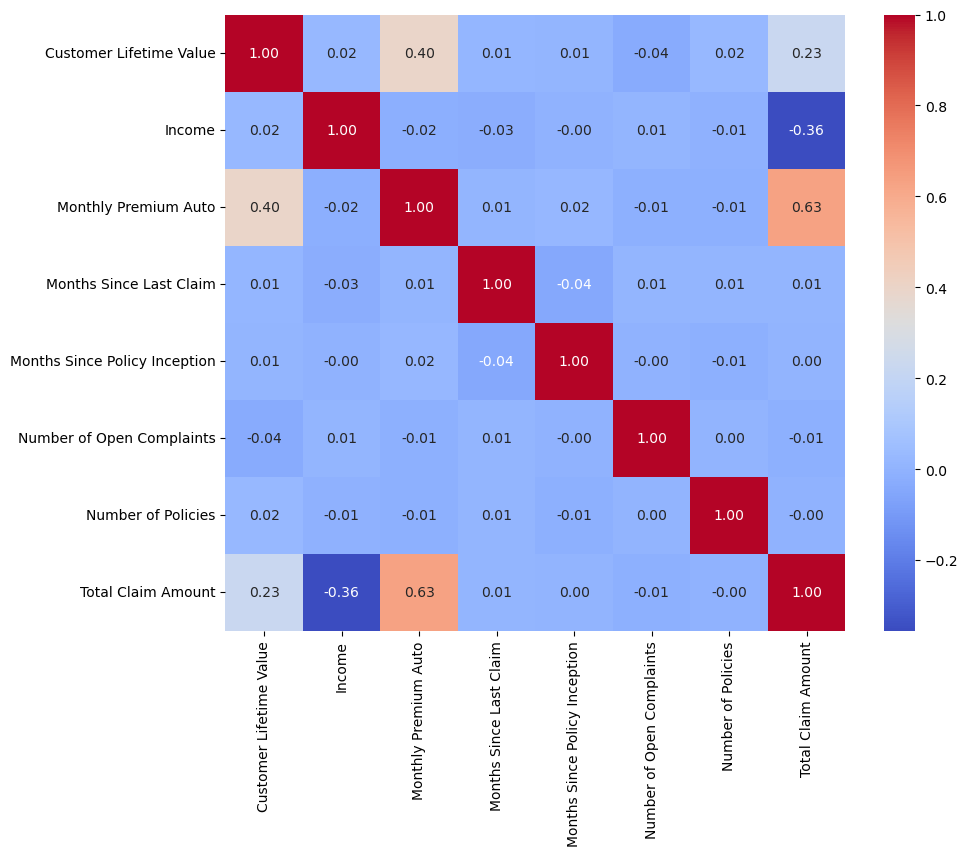

In [16]:
numeric_cols = ['Customer Lifetime Value', 'Income', 'Monthly Premium Auto',
				'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 
				'Number of Policies', 'Total Claim Amount']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

## Исследование зависимостей

1) Проверка связи Monthly Premium Auto с Total Claim Amount и Customer Lifetime Value

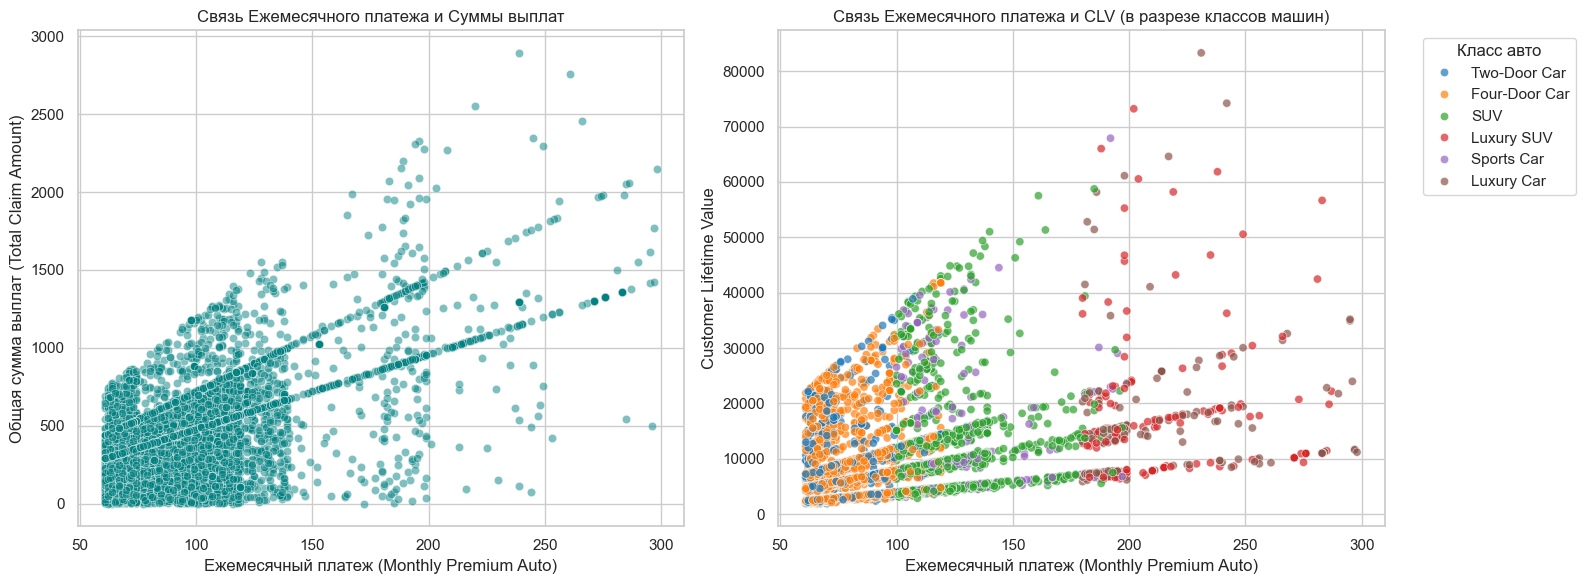

In [17]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Матрица корреляции 
correlation = df[['Monthly Premium Auto', 'Total Claim Amount', 'Customer Lifetime Value']].corr()
log("Коэффициенты корреляции Пирсона:")
log(correlation)

# График 1: Премия против Суммы выплат
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x='Monthly Premium Auto', y='Total Claim Amount', 
                alpha=0.5, ax=axes[0], color='teal')
axes[0].set_title('Связь Ежемесячного платежа и Суммы выплат')
axes[0].set_xlabel('Ежемесячный платеж (Monthly Premium Auto)')
axes[0].set_ylabel('Общая сумма выплат (Total Claim Amount)')

# График 2: Премия против CLV (добавим цвет по классам машин для инсайтов)
sns.scatterplot(data=df, x='Monthly Premium Auto', y='Customer Lifetime Value', 
                hue='Vehicle Class', alpha=0.7, ax=axes[1], palette='tab10')
axes[1].set_title('Связь Ежемесячного платежа и CLV (в разрезе классов машин)')
axes[1].set_xlabel('Ежемесячный платеж (Monthly Premium Auto)')
axes[1].set_ylabel('Customer Lifetime Value')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Класс авто')

plt.tight_layout()
plt.show()

Данные разделились на чёткие этажи:
1) Бюджетный класс двух\четырёх дверных авто, платят мало ценность растёт медленно
2) Средний класс SUV\sportcars, выше платёж и выше ценность
3) VIP наибольший платёж и значимость для компании
   
Vehicle Class — это один из важнейших категориальных признаков в датасете. Предположения о работе моделей бустинга:
- CatBoost справится идеально сам, так как он построит комбинации между Vehicle Class и числовым Monthly Premium Auto.
- XGBoost, обычный One-Hot Encoding может сработать хуже, здесь отлично зайдет Target Encoding (кодирование класса машины средним значением CLV).


2. Проверка связи с отсутствием дохода

Всего клиентов с нулевым доходом: 2317 (25.4%)

Распределение статуса занятости среди людей с нулевым доходом:
EmploymentStatus
Unemployed    2317
Name: count, dtype: int64


Сравнение средних показателей:
                         С доходом > 0  С нулевым доходом
Monthly Premium Auto         92.963034          93.973241
Total Claim Amount          377.840789         599.579795
Customer Lifetime Value    8130.229340        7636.319761
Response                      0.162828           0.085455


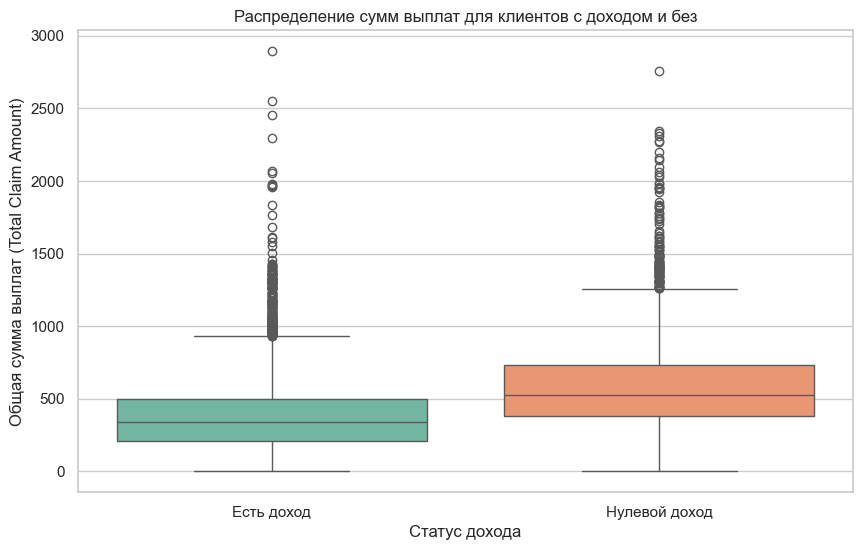

In [18]:
# Кто эти люди с нулевым доходом?

# Приведём Response к бинарному виду
log(df['Response'].unique())
df['Response'] = df['Response'].str.strip().str.lower()
df['Response'] = df['Response'].map({'yes': 1, 'no': 0}).fillna(0).astype(int)
log(df['Response'].unique())

zero_income_df = df[df['Income'] == 0]
not_zero_income_df = df[df['Income'] > 0]

print(f"Всего клиентов с нулевым доходом: {len(zero_income_df)} ({len(zero_income_df)/len(df)*100:.1f}%)")
print("\nРаспределение статуса занятости среди людей с нулевым доходом:")
print(zero_income_df['EmploymentStatus'].value_counts(dropna=False))
print("\n" + "="*50 + "\n")

# Сравнительный анализ: Как ведут себя «нулевые» по сравнению с остальными?
# Посмотрим на средний чек страховки, выплаты и отклик на маркетинг
metrics = ['Monthly Premium Auto', 'Total Claim Amount', 'Customer Lifetime Value', 'Response']

print("Сравнение средних показателей:")
compare_table = pd.DataFrame({
    'С доходом > 0': not_zero_income_df[metrics].mean(),
    'С нулевым доходом': zero_income_df[metrics].mean()
})
print(compare_table)

# Визуализируем разницу в убыточности (Total Claim Amount) через Boxplot
plt.figure(figsize=(10, 6))
# Создадим временный признак для графика
df['Has_Income'] = df['Income'].apply(lambda x: 'Есть доход' if x > 0 else 'Нулевой доход')

sns.boxplot(data=df, x='Has_Income', y='Total Claim Amount', hue='Has_Income', palette='Set2', legend=False)
plt.title('Распределение сумм выплат для клиентов с доходом и без')
plt.xlabel('Статус дохода')
plt.ylabel('Общая сумма выплат (Total Claim Amount)')
plt.show()

# Чистим временную колонку
df.drop(columns=['Has_Income'], inplace=True)

На графике отчетливо видна огромная разница в поведении двух групп клиентов:
- Клиенты с доходом («Есть доход»): Медиана выплат находится на уровне примерно 350. Большинство клиентов укладываются в диапазон до 500, а всё, что выше 950, уже считается редкими выбросами (точками).
- Клиенты без дохода («Нулевой доход»): Медиана выплат подскочила почти до 530! Весь «ящик» (где сидят 50% типичных клиентов этой группы) сильно смещен вверх. Они стабильно и массово требуют от страховой компании гораздо больше денег.

Для алгоритмов бустинга (XGBoost, LightGBM, CatBoost) это идеальный сигнал:
1. Деревья решений мгновенно сделают сплит (разделение) по условию Income > 0.
2. Модель сразу поймет, что если доход равен нулю, то базовый прогноз по выплатам (Total Claim Amount) нужно автоматически увеличивать примерно на 150–200$.

## Часть 2. Preprocessing & Feature Engineering

In [19]:
# Униккальные ID из датасета удалим
del df['Customer']

# Пол к 1 и 0 тоже
log(df['Gender'].unique())

# Переводим: F -> 1, M -> 0
df['Gender'] = df['Gender'].str.strip().str.lower()
df['Gender'] = df['Gender'].map({'m': 1, 'f': 0}).fillna(0).astype(int)

log(df['Gender'].unique())

In [20]:
# Добавим новые переменные:
# Соотношение выплат к ежемесячному платежу
df['Claim_to_Premium_Ratio'] = df['Total Claim Amount'] / df['Monthly Premium Auto']

# Флаг нулевого дохода (безработицы)
df['Is_Unemployed'] = (df['Income'] == 0).astype(int)

# Вспомогательное: Работа со сложной датой Effective To Date (с явным указанием формата)
df['Effective To Date'] = pd.to_datetime(df['Effective To Date'], format='%m/%d/%y')
df['Inception_Month'] = df['Effective To Date'].dt.month
df['Inception_Day'] = df['Effective To Date'].dt.day
df['Inception_DayOfWeek'] = df['Effective To Date'].dt.dayofweek

# Удаляем исходную дату
df.drop(columns=['Effective To Date'], inplace=True, errors='ignore')

# Кодирование категориальных (LabelEncoder)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Словарь для хранения энкодеров
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str).str.strip() 
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

log(f"Закодированы столбцы: {categorical_cols}")

## Разбиение на Train-Test, тестирование

In [21]:
target_col = 'Customer Lifetime Value'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Инициализируем модели по умолчанию
models_default = {
    "scikit-learn": HistGradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(random_seed=42, verbose=0)
}

# Тестируем каждую модель
for name, model in models_default.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    log(f"{name:12} -> MAE: ${mae:.2f} | R²: {r2:.4f}")

Теперь мы дадим каждому алгоритму шанс раскрыться, подобрав ключевые параметры:
- n_estimators (или max_iter / iterations) — количество деревьев.
- learning_rate — скорость обучения (шаг градиентного спуска).
- max_depth — глубина деревьев.

Чтобы эксперимент не занял слишком много времени, мы будем использовать GridSearchCV с 3 фолдами кросс-валидации и точечной сеткой параметров.

In [22]:
# 1. Настройка для scikit-learn
param_grid_sk = {
    'max_iter': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6]
}
grid_sk = GridSearchCV(HistGradientBoostingRegressor(random_state=42), param_grid_sk, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_sk.fit(X_train, y_train)
best_sk = grid_sk.best_estimator_
print(f"scikit-learn настроен. Лучшие параметры: {grid_sk.best_params_}")

# 2. Настройка для XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print(f"XGBoost настроен. Лучшие параметры: {grid_xgb.best_params_}")

# 3. Настройка для LightGBM
param_grid_lgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0]
}
grid_lgb = GridSearchCV(LGBMRegressor(random_state=42, verbose=-1), param_grid_lgb, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_lgb.fit(X_train, y_train)
best_lgb = grid_lgb.best_estimator_
print(f"LightGBM настроен. Лучшие параметры: {grid_lgb.best_params_}")

# 4. Настройка для CatBoost
param_grid_cat = {
    'iterations': [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6]
}
grid_cat = GridSearchCV(CatBoostRegressor(random_seed=42, verbose=0), param_grid_cat, cv=3, scoring='neg_mean_absolute_error', n_jobs=1) #catvoost валяется от путей или иных проблем с Windows
grid_cat.fit(X_train, y_train)
best_cat = grid_cat.best_estimator_
print(f"CatBoost настроен. Лучшие параметры: {grid_cat.best_params_}")

scikit-learn настроен. Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 6, 'max_iter': 100}
XGBoost настроен. Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
LightGBM настроен. Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
CatBoost настроен. Лучшие параметры: {'depth': 6, 'iterations': 100, 'learning_rate': 0.05}


Все четыре модели выбрали абсолютно одинаковые оптимальные параметры для этого датасета (learning_rate: 0.05 и глубину дерева 6). Это говорит о том, что структура данных имеет очень четко выраженные закономерности, которые все алгоритмы уловили одинаково.
Теперь проверка какая модель смогла выжать максимум точности на отложенной тестовой выборке (X_test), которую модели еще ни разу не видели.

In [23]:
# Тастроенные можели

tuned_models = {
    "scikit-learn": best_sk,
    "XGBoost": best_xgb,
    "LightGBM": best_lgb,
    "CatBoost": best_cat
}

# Тестируем на отложенной выборке X_test, y_test
for name, model in tuned_models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name:12} (Tuned) -> MAE: ${mae:.2f} | R²: {r2:.4f}")

scikit-learn (Tuned) -> MAE: $1580.69 | R²: 0.6808
XGBoost      (Tuned) -> MAE: $1581.93 | R²: 0.6734
LightGBM     (Tuned) -> MAE: $1591.39 | R²: 0.6814
CatBoost     (Tuned) -> MAE: $1670.95 | R²: 0.6791


победитель по точности (MAE): scikit-learn, модель показала самую низкую среднюю ошибку: всего $1580.69

По объясненной дисперсии (R²): LightGBM (68.14% изменчивости CLV успешно объяснено моделью). При этом его MAE ($1591.39) отстает от лидера всего на 10 долларов.

CatBoost отстал сильнее всех, показав ошибку $1670.95, главная причина — мы принудительно ограничили его сетку всего 100 итерациями (iterations: 100) и зажали перебор в жесткие рамки, чтобы обойти ошибку кодировки Windows. По своей природе CatBoost «из коробки» обучается медленнее (ему обычно нужно 1000+ деревьев с маленьким шагом), поэтому на 100 деревьях он просто не успел полностью раскрыть свой потенциал.

## То же тестирование но сглаженных данных

In [24]:
# Берем уже настроенные лучшие модели из предыдущего шага
models_log_test = {
    "scikit-learn": best_sk,
    "XGBoost": best_xgb,
    "LightGBM": best_lgb,
    "CatBoost": best_cat
}


for name, model in models_log_test.items():
    # ОБУЧЕНИЕ на логарифме
    model.fit(X_train, np.log1p(y_train))
    
    # ПРЕДСКАЗАНИЕ (в результате получаем логарифмы)
    preds_log = model.predict(X_test)
    
    # ТРАНСФОРМАЦИЯ обратно в доллары
    preds_final = np.expm1(preds_log)
    
    # Считаем метрики в реальных долларах
    mae = mean_absolute_error(y_test, preds_final)
    r2 = r2_score(y_test, preds_final)
    
    print(f"{name:12} (Log-Tuned) -> MAE: ${mae:.2f} | R²: {r2:.4f}")

scikit-learn (Log-Tuned) -> MAE: $1469.87 | R²: 0.6631
XGBoost      (Log-Tuned) -> MAE: $1455.75 | R²: 0.6620
LightGBM     (Log-Tuned) -> MAE: $1473.58 | R²: 0.6603
CatBoost     (Log-Tuned) -> MAE: $1524.64 | R²: 0.6593


Теперь XGBoost вырвался в абсолютные лидеры с результатом $1455.75
Это означает, что в среднем модель теперь ошибается в стоимости клиента гораздо меньше.

Почему упал R²?
Метрика R² безумно чувствительна к крупным выбросам (VIP-клиентам), так как в её основе лежит квадрат ошибки Е. Когда модели учились на «сырых» данных, они изо всех сил пытались угадать гигантские чеки VIP-ов, жертвуя точностью на обычных людях (поэтому MAE был хуже, а R² чуть выше). Теперь же, обучаясь на логарифме, модели стали гораздо точнее предсказывать обычных массовых клиентов (MAE улучшился), но перестали гнаться за идеальным попаданием в супер-выбросы (поэтому R² немного просел).

Для бизнеса MAE в $1455 гораздо полезнее, так как модель стала стабильной для большинства клиентов.

## Проверка Feature Importance

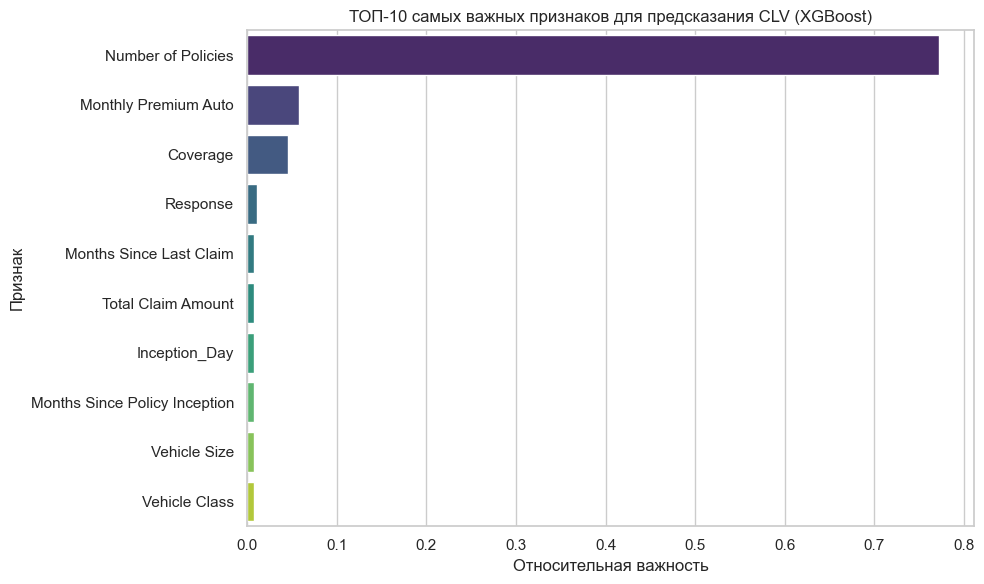

In [25]:
# Получаем важность признаков от нашего победителя XGBoost
importances = best_xgb.feature_importances_
features = X_train.columns

# Создаем датафрейм для удобства
feat_imp_df = pd.DataFrame({
    'Признак': features,
    'Важность': importances
}).sort_values(by='Важность', ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(10), 
    x='Важность', 
    y='Признак', 
    hue='Признак', 
    palette='viridis', 
    legend=False
)
plt.title('ТОП-10 самых важных признаков для предсказания CLV (XGBoost)')
plt.xlabel('Относительная важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

## Итоги

Победил XGBoost,

Вывод для бизнеса: количество проданных страховок одному клиенту важнее того что это за клиент.